**Step 1. Training Dataset**

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!ls "/content/drive/My Drive/ECE_651_Final_Images"


0.png	 191.png  282.png  373.png  464.png  555.png  646.png  737.png	828.png  919.png
100.png  192.png  283.png  374.png  465.png  556.png  647.png  738.png	829.png  91.png
101.png  193.png  284.png  375.png  466.png  557.png  648.png  739.png	82.png	 920.png
102.png  194.png  285.png  376.png  467.png  558.png  649.png  73.png	830.png  921.png
103.png  195.png  286.png  377.png  468.png  559.png  64.png   740.png	831.png  922.png
104.png  196.png  287.png  378.png  469.png  55.png   650.png  741.png	832.png  923.png
105.png  197.png  288.png  379.png  46.png   560.png  651.png  742.png	833.png  924.png
106.png  198.png  289.png  37.png   470.png  561.png  652.png  743.png	834.png  925.png
107.png  199.png  28.png   380.png  471.png  562.png  653.png  744.png	835.png  926.png
108.png  19.png   290.png  381.png  472.png  563.png  654.png  745.png	836.png  927.png
109.png  1.png	  291.png  382.png  473.png  564.png  655.png  746.png	837.png  928.png
10.png	 200.png  292.png  383.png  474

In [3]:
import os
import numpy as np
from PIL import Image

folder_path = "/content/drive/My Drive/ECE_651_Final_Images"

all_images = sorted([f for f in os.listdir(folder_path) if f.endswith(".png")])

# Select filenames for images ranging from 0 to 999.
selected_images = [f"{i}.png" for i in range(1000)]

binary_mazes = []

# Read each image and convert it into a binary matrix.
for image_name in selected_images:
    image_path = os.path.join(folder_path, image_name)
    if os.path.exists(image_path):
        with Image.open(image_path) as img:
            grayscale = img.convert("L")
            img_array = np.array(grayscale)
            binary_matrix = (img_array < 128).astype(int)
            binary_mazes.append(binary_matrix)

print(f"Processed {len(binary_mazes)} maze images, below is the first binary matrix：")
print(binary_mazes[0])

# Image directory
image_folder = "/content/drive/My Drive/ECE_651_Final_Images"

# Save the file.
output_file = os.path.join(image_folder, "binary_mazes.npy")
np.save(output_file, binary_mazes)
print(f"The binary matrix has been saved to {output_file}")

Processed 1000 maze images, below is the first binary matrix：
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]
The binary matrix has been saved to /content/drive/My Drive/ECE_651_Final_Images/binary_mazes.npy


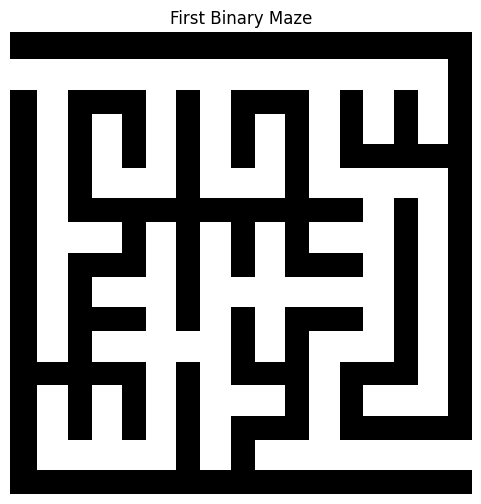

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(binary_mazes[0], cmap="binary")
plt.title("First Binary Maze")
plt.axis("off")
plt.show()


**Perform unique solution validation for each maze in the dataset:**

In [5]:
from scipy.ndimage import label

def is_unique_solution(maze):
    """
    Validate whether the maze has a unique solution.
    :param maze: Binary maze matrix.
    :return: True if there is a unique solution, otherwise False.
    """
    # Convert the maze into an inverted binary matrix (path as 1, wall as 0).
    inverted_maze = 1 - maze
    labeled, num_features = label(inverted_maze)

    # If there is more than one connected region, it is a multiple solution
    return num_features == 1

# Validate all mazes.
for i, maze in enumerate(binary_mazes):
    if not is_unique_solution(maze):
        print(f"Maze {i} does not have a unique solution.")
    else:
        print(f"Maze {i} has a unique solution.")

Maze 0 has a unique solution.
Maze 1 has a unique solution.
Maze 2 has a unique solution.
Maze 3 has a unique solution.
Maze 4 has a unique solution.
Maze 5 has a unique solution.
Maze 6 has a unique solution.
Maze 7 has a unique solution.
Maze 8 has a unique solution.
Maze 9 has a unique solution.
Maze 10 has a unique solution.
Maze 11 has a unique solution.
Maze 12 has a unique solution.
Maze 13 has a unique solution.
Maze 14 has a unique solution.
Maze 15 has a unique solution.
Maze 16 has a unique solution.
Maze 17 has a unique solution.
Maze 18 has a unique solution.
Maze 19 has a unique solution.
Maze 20 has a unique solution.
Maze 21 has a unique solution.
Maze 22 has a unique solution.
Maze 23 has a unique solution.
Maze 24 has a unique solution.
Maze 25 has a unique solution.
Maze 26 has a unique solution.
Maze 27 has a unique solution.
Maze 28 has a unique solution.
Maze 29 has a unique solution.
Maze 30 has a unique solution.
Maze 31 has a unique solution.
Maze 32 has a uniq

**Step 2. GAN-based Maze Generator**

**•	Configuration 1: Fully Connected GAN**

Use the device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch 0 - D Loss: 0.9895715713500977, G Loss: 0.17571523785591125
GAN: Save the best generator model (G Loss: 0.17571523785591125)


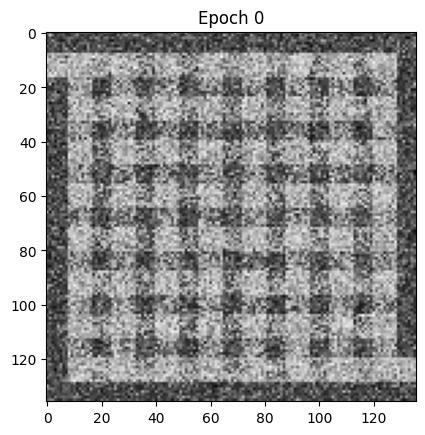

GAN: Save the generated maze to: /content/drive/MyDrive/ECE_651_Final_Generated/GAN_generated_maze_epoch_0.png
Epoch 100 - D Loss: 0.6586505174636841, G Loss: 1.0622239112854004
Epoch 200 - D Loss: 0.053129974752664566, G Loss: 2.6642911434173584
Epoch 300 - D Loss: 0.0032439108472317457, G Loss: 5.2769622802734375


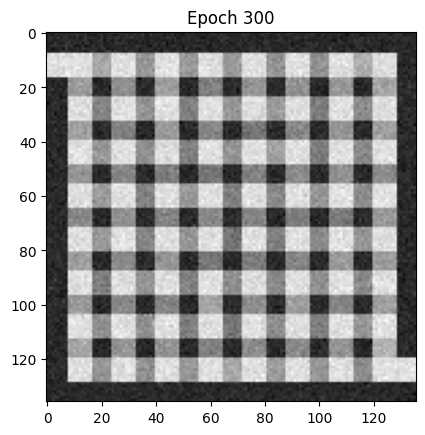

GAN: Save the generated maze to: /content/drive/MyDrive/ECE_651_Final_Generated/GAN_generated_maze_epoch_300.png
Epoch 400 - D Loss: 0.0001997752842726186, G Loss: 7.928665637969971
Epoch 500 - D Loss: 0.011962629854679108, G Loss: 7.86659574508667
Epoch 600 - D Loss: 0.0807415246963501, G Loss: 5.844969749450684


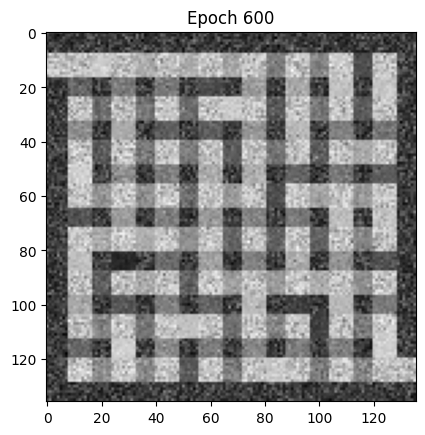

GAN: Save the generated maze to: /content/drive/MyDrive/ECE_651_Final_Generated/GAN_generated_maze_epoch_600.png
Epoch 700 - D Loss: 0.011787638068199158, G Loss: 6.384335994720459
Epoch 800 - D Loss: 0.00038791634142398834, G Loss: 8.375859260559082
Epoch 900 - D Loss: 0.003641067771241069, G Loss: 4.033557415008545


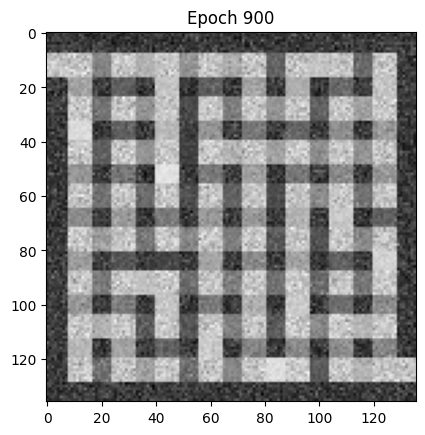

GAN: Save the generated maze to: /content/drive/MyDrive/ECE_651_Final_Generated/GAN_generated_maze_epoch_900.png
Epoch 1000 - D Loss: 0.001885211793705821, G Loss: 5.252849578857422
Epoch 1100 - D Loss: 0.009264393709599972, G Loss: 5.427382469177246
Epoch 1200 - D Loss: 0.0013173704501241446, G Loss: 7.947009086608887


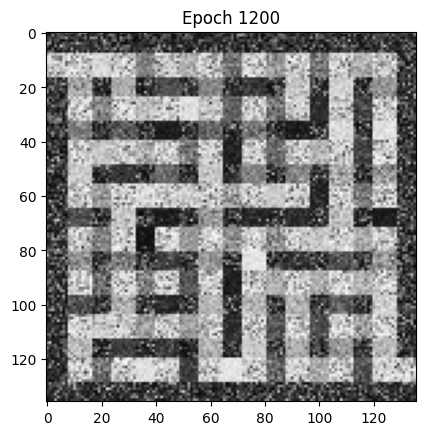

GAN: Save the generated maze to: /content/drive/MyDrive/ECE_651_Final_Generated/GAN_generated_maze_epoch_1200.png
Epoch 1300 - D Loss: 0.005513895768672228, G Loss: 6.582893371582031
Epoch 1400 - D Loss: 0.002294204430654645, G Loss: 7.913341522216797
Epoch 1500 - D Loss: 0.18608726561069489, G Loss: 7.14773416519165


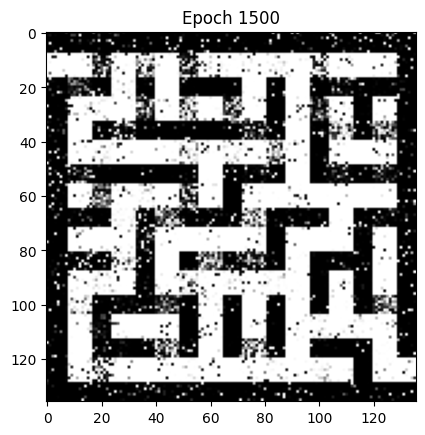

GAN: Save the generated maze to: /content/drive/MyDrive/ECE_651_Final_Generated/GAN_generated_maze_epoch_1500.png
Epoch 1600 - D Loss: 0.03505250811576843, G Loss: 6.617849349975586
Epoch 1700 - D Loss: 0.011956780217587948, G Loss: 7.201214790344238
Epoch 1800 - D Loss: 0.12038549035787582, G Loss: 5.750400543212891


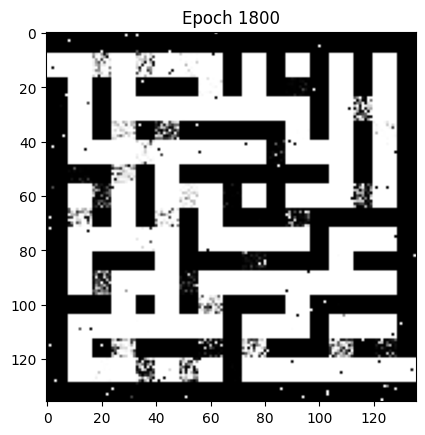

GAN: Save the generated maze to: /content/drive/MyDrive/ECE_651_Final_Generated/GAN_generated_maze_epoch_1800.png
Epoch 1900 - D Loss: 0.0031322715803980827, G Loss: 7.8633222579956055
Epoch 2000 - D Loss: 0.010379450395703316, G Loss: 6.256173133850098
Epoch 2100 - D Loss: 0.0567772351205349, G Loss: 4.483861923217773


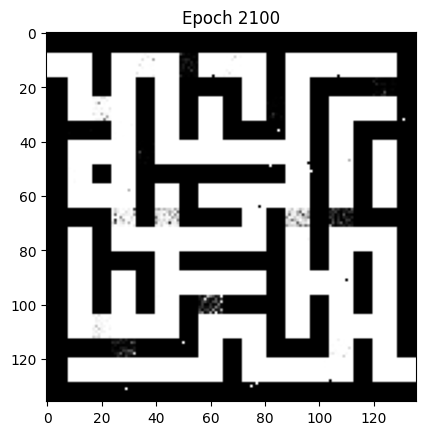

GAN: Save the generated maze to: /content/drive/MyDrive/ECE_651_Final_Generated/GAN_generated_maze_epoch_2100.png
Epoch 2200 - D Loss: 0.06205011159181595, G Loss: 6.8707685470581055
Epoch 2300 - D Loss: 0.00963041465729475, G Loss: 6.063094615936279
Epoch 2400 - D Loss: 0.0027337302453815937, G Loss: 5.943252086639404


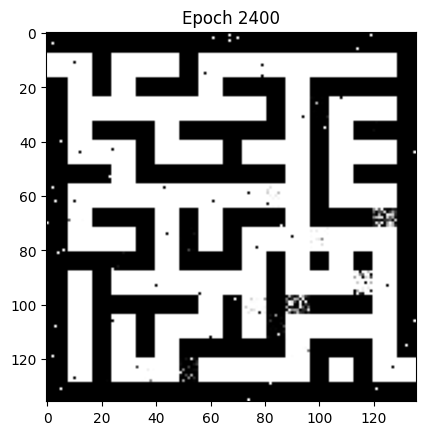

GAN: Save the generated maze to: /content/drive/MyDrive/ECE_651_Final_Generated/GAN_generated_maze_epoch_2400.png
Epoch 2500 - D Loss: 0.00261280732229352, G Loss: 7.540949821472168
Epoch 2600 - D Loss: 0.12368036806583405, G Loss: 7.031451225280762
Epoch 2700 - D Loss: 0.13230325281620026, G Loss: 7.313362121582031


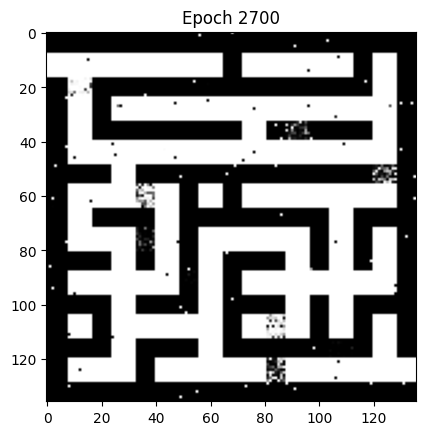

GAN: Save the generated maze to: /content/drive/MyDrive/ECE_651_Final_Generated/GAN_generated_maze_epoch_2700.png
Epoch 2800 - D Loss: 0.005137288477271795, G Loss: 6.665726184844971
Epoch 2900 - D Loss: 0.10813482105731964, G Loss: 8.092610359191895
Epoch 3000 - D Loss: 0.0038277623243629932, G Loss: 6.314594268798828


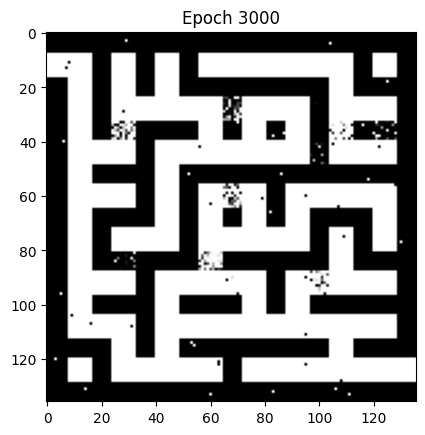

GAN: Save the generated maze to: /content/drive/MyDrive/ECE_651_Final_Generated/GAN_generated_maze_epoch_3000.png
Training complete.


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from google.colab import drive
import os
import random

# Fix the random seed.
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(12)  # for A100 GPU (colab)

# Check the GPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Use the device: {device}")

# Define a Generator
class Generator(nn.Module):
    def __init__(self, latent_dim, img_size):
        super(Generator, self).__init__()
        self.img_size = img_size
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, img_size * img_size),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(z.size(0), 1, self.img_size, self.img_size)
        return img

# Define a Discriminator
class Discriminator(nn.Module):
    def __init__(self, img_size):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(img_size * img_size, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        validity = self.model(img)
        return validity

# Initialize Google Drive.
drive.mount('/content/drive')
folder_path = "/content/drive/MyDrive/ECE_651_Final_Images"
output_dir = "/content/drive/MyDrive/ECE_651_Final_Generated"
os.makedirs(output_dir, exist_ok=True)

# Load data.
binary_mazes = np.load(f"{folder_path}/binary_mazes.npy")
binary_mazes = (binary_mazes * 2) - 1
binary_mazes_tensor = torch.tensor(binary_mazes, dtype=torch.float32)
dataloader = DataLoader(binary_mazes_tensor, batch_size=32, shuffle=True)

# Set parameters.
latent_dim = 100
img_size = binary_mazes_tensor.shape[1]
generator = Generator(latent_dim, img_size).to(device)
discriminator = Discriminator(img_size).to(device)
adversarial_loss = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=0.0001)
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0001)

# Training parameters.
epochs = 3100
best_g_loss = float('inf')  # Initialize the best generator loss.

# Training process
for epoch in range(epochs):
    for imgs in dataloader:
        imgs = imgs.to(device).unsqueeze(1)  # Add the channel dimension.
        valid = torch.ones(imgs.size(0), 1, device=device)
        fake = torch.zeros(imgs.size(0), 1, device=device)

        # Train the generator.
        optimizer_G.zero_grad()
        z = torch.randn(imgs.size(0), latent_dim, device=device)
        gen_imgs = generator(z)
        g_loss = adversarial_loss(discriminator(gen_imgs), valid)
        g_loss.backward()
        optimizer_G.step()

        # Train the discriminator.
        optimizer_D.zero_grad()
        real_loss = adversarial_loss(discriminator(imgs), valid)
        fake_loss = adversarial_loss(discriminator(gen_imgs.detach()), fake)
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

    # Print the loss.
    if epoch % 100 == 0:
        print(f"Epoch {epoch} - D Loss: {d_loss.item()}, G Loss: {g_loss.item()}")

    # Save the best generator model.
    if g_loss.item() < best_g_loss:
        best_g_loss = g_loss.item()
        torch.save(generator.state_dict(), os.path.join(output_dir, "GAN_Best_Generator.pth"))
        print(f"GAN: Save the best generator model (G Loss: {best_g_loss})")

    # Visualize the generated maze.
    if epoch % 300 == 0:
        with torch.no_grad():
            sample_z = torch.randn(1, latent_dim, device=device)
            sample_img = generator(sample_z).squeeze().cpu().numpy()
            inverted_img = 1 - ((sample_img + 1) / 2)
            plt.imshow(inverted_img, cmap="gray")
            plt.title(f"Epoch {epoch}")
            plt.show()

            output_file = os.path.join(output_dir, f"GAN_generated_maze_epoch_{epoch}.png")
            plt.imsave(output_file, inverted_img, cmap="gray")
            print(f"GAN: Save the generated maze to: {output_file}")

print("Training complete.")


**Step 2. GAN-based Maze Generator**

**•	Configuration 2: Deep Convolutional Generative Adversarial Network (DCGAN)**

Use the device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
img_size: 136
Epoch 0 - D Loss: 0.001243453472852707, G Loss: 6.420779228210449
DGAN: Save the best generator model. (G Loss: 6.420779228210449)


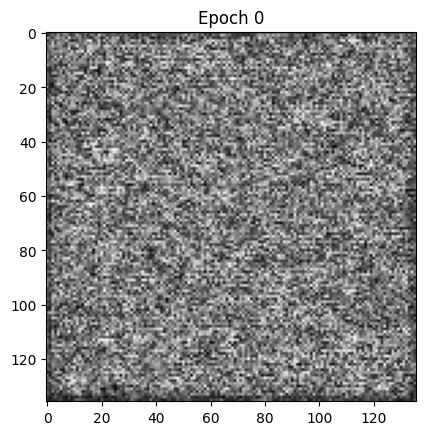

DGAN: Save the generated maze to: /content/drive/MyDrive/ECE_651_Final_Generated/generated_maze_epoch_0.png
DGAN: Save the best generator model. (G Loss: 5.625351905822754)
DGAN: Save the best generator model. (G Loss: 5.492159843444824)
DGAN: Save the best generator model. (G Loss: 4.347662925720215)
DGAN: Save the best generator model. (G Loss: 3.8998804092407227)
DGAN: Save the best generator model. (G Loss: 3.5538363456726074)
DGAN: Save the best generator model. (G Loss: 3.093174934387207)
DGAN: Save the best generator model. (G Loss: 0.03605484589934349)
Epoch 100 - D Loss: 0.11966203153133392, G Loss: 2.434525728225708
DGAN: Save the best generator model. (G Loss: 0.0004363096959423274)
Epoch 200 - D Loss: 0.008409494534134865, G Loss: 6.457799911499023
Epoch 300 - D Loss: 0.0003710415621753782, G Loss: 9.988271713256836
Epoch 400 - D Loss: 50.0, G Loss: 100.0
Epoch 500 - D Loss: 50.0, G Loss: 100.0


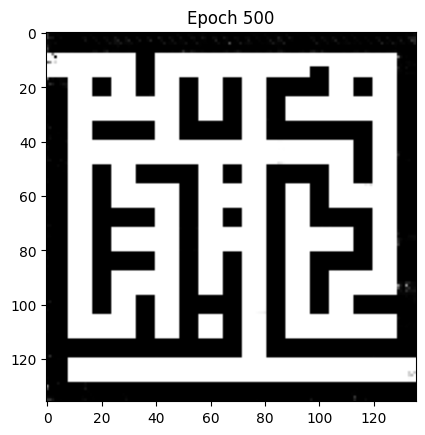

DGAN: Save the generated maze to: /content/drive/MyDrive/ECE_651_Final_Generated/generated_maze_epoch_500.png
Epoch 600 - D Loss: 50.0, G Loss: 100.0
Epoch 700 - D Loss: 50.0, G Loss: 100.0
Epoch 800 - D Loss: 50.0, G Loss: 100.0
Epoch 900 - D Loss: 50.0, G Loss: 100.0
Epoch 1000 - D Loss: 50.0, G Loss: 100.0


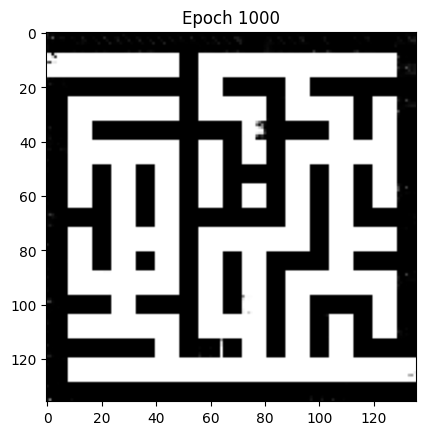

DGAN: Save the generated maze to: /content/drive/MyDrive/ECE_651_Final_Generated/generated_maze_epoch_1000.png
Epoch 1100 - D Loss: 50.0, G Loss: 100.0
Epoch 1200 - D Loss: 50.0, G Loss: 100.0
Epoch 1300 - D Loss: 50.0, G Loss: 100.0
Epoch 1400 - D Loss: 50.0, G Loss: 100.0
Epoch 1500 - D Loss: 50.0, G Loss: 100.0


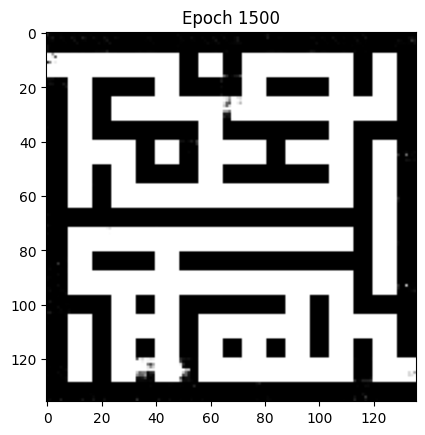

DGAN: Save the generated maze to: /content/drive/MyDrive/ECE_651_Final_Generated/generated_maze_epoch_1500.png
Epoch 1600 - D Loss: 50.0, G Loss: 100.0
Epoch 1700 - D Loss: 50.0, G Loss: 100.0
Epoch 1800 - D Loss: 50.0, G Loss: 100.0
Epoch 1900 - D Loss: 50.0, G Loss: 100.0
Epoch 2000 - D Loss: 50.0, G Loss: 100.0


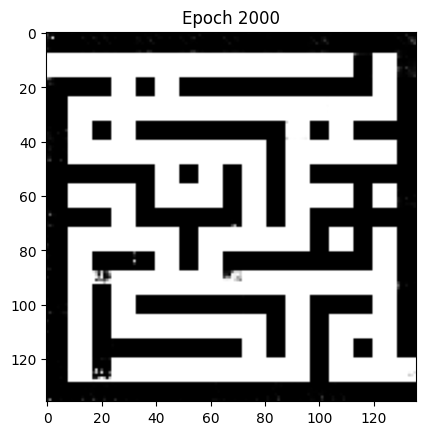

DGAN: Save the generated maze to: /content/drive/MyDrive/ECE_651_Final_Generated/generated_maze_epoch_2000.png
Training complete.


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from google.colab import drive
import os
import random

# Set a fixed random seed.
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(23) # for A100 GPU (colab)

# Check GPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Use the device: {device}")

# Define a Generator.
class Generator(nn.Module):
    def __init__(self, latent_dim, img_size):
        super(Generator, self).__init__()
        self.init_size = img_size // 4
        self.fc = nn.Linear(latent_dim, 128 * self.init_size * self.init_size)
        self.model = nn.Sequential(
            nn.ConvTranspose2d(128, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Conv2d(64, 1, 3, stride=1, padding=1),
            nn.Tanh(),
        )

    def forward(self, z):
        out = self.fc(z)
        out = out.view(out.size(0), 128, self.init_size, self.init_size)
        img = self.model(out)
        return img

# Define a Discriminator
class Discriminator(nn.Module):
    def __init__(self, img_size):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(128 * (img_size // 4) * (img_size // 4), 1),
            nn.Sigmoid(),
        )

    def forward(self, img):
        validity = self.model(img)
        return validity

# Initialize Google Drive.
drive.mount('/content/drive')
folder_path = "/content/drive/MyDrive/ECE_651_Final_Images"
output_dir = "/content/drive/MyDrive/ECE_651_Final_Generated"
os.makedirs(output_dir, exist_ok=True)

# Load data.
binary_mazes = np.load(f"{folder_path}/binary_mazes.npy")
binary_mazes = (binary_mazes * 2) - 1
binary_mazes_tensor = torch.tensor(binary_mazes, dtype=torch.float32).unsqueeze(1)

dataloader = DataLoader(binary_mazes_tensor, batch_size=32, shuffle=True)

# Set parameters.
latent_dim = 100
print(f"img_size: {binary_mazes_tensor.shape[2]}")
img_size = binary_mazes_tensor.shape[2]
generator = Generator(latent_dim, img_size).to(device)
discriminator = Discriminator(img_size).to(device)

adversarial_loss = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=0.0001, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999))

# Training parameters.
epochs = 2100
best_g_loss = float('inf')

# Training process.
for epoch in range(epochs):
    for imgs in dataloader:
        imgs = imgs.to(device)
        valid = torch.ones(imgs.size(0), 1, device=device)
        fake = torch.zeros(imgs.size(0), 1, device=device)

        # Train the generator.
        optimizer_G.zero_grad()
        z = torch.randn(imgs.size(0), latent_dim, device=device)
        gen_imgs = generator(z)
        g_loss = adversarial_loss(discriminator(gen_imgs), valid)
        g_loss.backward()
        optimizer_G.step()

        # Train the discriminator.
        optimizer_D.zero_grad()
        real_loss = adversarial_loss(discriminator(imgs), valid)
        fake_loss = adversarial_loss(discriminator(gen_imgs.detach()), fake)
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

    # Print the loss.
    if epoch % 100 == 0:
        print(f"Epoch {epoch} - D Loss: {d_loss.item()}, G Loss: {g_loss.item()}")

    # Save the best generator model.
    if g_loss.item() < best_g_loss:
        best_g_loss = g_loss.item()
        torch.save(generator.state_dict(), os.path.join(output_dir, "DCGAN_best_generator.pth"))
        print(f"DGAN: Save the best generator model. (G Loss: {best_g_loss})")

    # Visualize the generated maze.
    if epoch % 500 == 0:
        with torch.no_grad():
            sample_z = torch.randn(1, latent_dim, device=device)
            sample_img = generator(sample_z).squeeze().cpu().numpy()
            inverted_img = 1 - ((sample_img + 1) / 2)
            plt.imshow(inverted_img, cmap="gray")
            plt.title(f"Epoch {epoch}")
            plt.show()

            output_file = os.path.join(output_dir, f"generated_maze_epoch_{epoch}.png")
            plt.imsave(output_file, inverted_img, cmap="gray")
            print(f"DGAN: Save the generated maze to: {output_file}")

print("Training complete.")


**Step 3. DRL-based Maze Generator**

Using device: cuda
Epoch 0, Total Reward: -230.00, Epsilon: 0.99
Epoch 1, Total Reward: -130.00, Epsilon: 0.99
Epoch 2, Total Reward: -30.00, Epsilon: 0.99
Epoch 3, Total Reward: -180.00, Epsilon: 0.98
Epoch 4, Total Reward: -60.00, Epsilon: 0.98
Epoch 5, Total Reward: -180.00, Epsilon: 0.97
Epoch 6, Total Reward: -60.00, Epsilon: 0.97
Epoch 7, Total Reward: -110.00, Epsilon: 0.96
Epoch 8, Total Reward: -40.00, Epsilon: 0.96
Epoch 9, Total Reward: -10.00, Epsilon: 0.95
Epoch 10, Total Reward: -160.00, Epsilon: 0.95
Epoch 11, Total Reward: -190.00, Epsilon: 0.94
Epoch 12, Total Reward: -50.00, Epsilon: 0.94
Epoch 13, Total Reward: -40.00, Epsilon: 0.93
Epoch 14, Total Reward: -30.00, Epsilon: 0.93
Epoch 15, Total Reward: -420.00, Epsilon: 0.92
Epoch 16, Total Reward: -80.00, Epsilon: 0.92
Epoch 17, Total Reward: -140.00, Epsilon: 0.91
Epoch 18, Total Reward: -120.00, Epsilon: 0.91
Epoch 19, Total Reward: -30.00, Epsilon: 0.90
Epoch 20, Total Reward: -30.00, Epsilon: 0.90
Epoch 21, Total

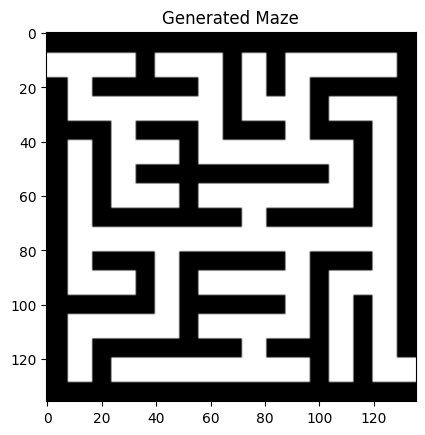

In [9]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt
from queue import Queue

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load binary maze dataset
def load_binary_mazes(filepath):
    return np.load(filepath, allow_pickle=True)

# Ensure directory is correct and load binary mazes
binary_mazes_file = "/content/drive/My Drive/ECE_651_Final_Images/binary_mazes.npy"
binary_mazes = load_binary_mazes(binary_mazes_file)
maze_size = binary_mazes[0].shape[0]  # Assume all mazes are of the same size
state_dim = maze_size * maze_size

# Replay Buffer
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        samples = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*samples)
        return np.array(states), actions, rewards, np.array(next_states), dones

    def size(self):
        return len(self.buffer)

# DQN Model
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.model(x)

# Epsilon-Greedy Policy
class EpsilonGreedyPolicy:
    def __init__(self, start_eps, end_eps, decay):
        self.start_eps = start_eps
        self.end_eps = end_eps
        self.decay = decay
        self.eps = start_eps

    def select_action(self, model, state, action_dim):
        if random.random() < self.eps:
            return random.randint(0, action_dim - 1)
        else:
            with torch.no_grad():
                state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
                q_values = model(state)
                return torch.argmax(q_values).item()

    def update(self):
        self.eps = max(self.end_eps, self.eps * self.decay)

# Add start and goal points to the maze
def initialize_maze_with_start_goal(maze):
    maze = maze.copy()
    maze[0, 0] = 2  # Start point
    maze[-1, -1] = 3  # Goal point
    return maze

# BFS solvability check
def is_solvable(maze):
    start = tuple(np.argwhere(maze == 2)[0])  # Starting point
    goal = tuple(np.argwhere(maze == 3)[0])  # Goal point
    visited = set()
    queue = Queue()
    queue.put(start)
    visited.add(start)

    while not queue.empty():
        current = queue.get()
        if current == goal:
            return True
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            next_pos = (current[0] + dx, current[1] + dy)
            if (0 <= next_pos[0] < maze_size and 0 <= next_pos[1] < maze_size and
                next_pos not in visited and maze[next_pos] != 1):
                queue.put(next_pos)
                visited.add(next_pos)
    return False

# Apply action to the maze
def apply_action_safe(maze, action):
    maze = maze.copy()
    pos = divmod(action, maze_size)  # Decode action to position in the maze
    original_value = maze[pos]
    maze[pos] = 1 - maze[pos]  # Toggle wall and empty space
    maze[0, 0] = 2  # Ensure start point remains
    maze[-1, -1] = 3  # Ensure goal point remains
    if not is_solvable(maze):  # Revert if maze becomes unsolvable
        maze[pos] = original_value
    return maze

# Reward function
def calculate_reward(maze):
    if not is_solvable(maze):
        return -10  # Penalty for unsolvable maze
    path_length = np.sum(maze == 0)
    return path_length / (maze_size * maze_size)

# Initialize parameters
action_dim = maze_size * maze_size
buffer_capacity = 10000
batch_size = 64
epsilon_start = 1.0
epsilon_end = 0.01
epsilon_decay = 0.995
learning_rate = 0.001
epochs = 500

# Initialize
buffer = ReplayBuffer(buffer_capacity)
policy = EpsilonGreedyPolicy(epsilon_start, epsilon_end, epsilon_decay)
model = DQN(state_dim, action_dim).to(device)
target_model = DQN(state_dim, action_dim).to(device)
target_model.load_state_dict(model.state_dict())
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training
for epoch in range(epochs):
    maze = random.choice(binary_mazes)
    maze = initialize_maze_with_start_goal(maze)
    state = maze.flatten()
    total_reward = 0

    while True:
        action = policy.select_action(model, state, action_dim)
        next_maze = apply_action_safe(maze, action)
        reward = calculate_reward(next_maze)

        done = random.random() < 0.1
        next_state = next_maze.flatten()
        buffer.add(state, action, reward, next_state, done)

        if buffer.size() >= batch_size:
            states, actions, rewards, next_states, dones = buffer.sample(batch_size)
            states = torch.tensor(states, dtype=torch.float32).to(device)
            actions = torch.tensor(actions).to(device)
            rewards = torch.tensor(rewards, dtype=torch.float32).to(device)
            next_states = torch.tensor(next_states, dtype=torch.float32).to(device)
            dones = torch.tensor(dones, dtype=torch.float32).to(device)

            q_values = model(states).gather(1, actions.unsqueeze(-1)).squeeze(-1)
            next_q_values = target_model(next_states).max(1)[0]
            targets = rewards + (1 - dones) * 0.99 * next_q_values

            loss = nn.MSELoss()(q_values, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        state = next_state
        maze = next_maze
        total_reward += reward

        if done:
            break

    policy.update()
    if epoch % 10 == 0:
        target_model.load_state_dict(model.state_dict())

    print(f"Epoch {epoch}, Total Reward: {total_reward:.2f}, Epsilon: {policy.eps:.2f}")

# Test generated maze
final_maze = maze.reshape(maze_size, maze_size)
plt.imshow(final_maze, cmap="binary", vmin=0, vmax=1)  # Ensure black and white with fixed range
plt.title("Generated Maze")
plt.show()
